In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.patches import Ellipse

In [9]:
df_complete = pd.read_csv('VELSIPITY_cleaned_igna.csv')

# Muestras
df = df_complete.sample(n=min(5000, len(df_complete)), random_state=42)
df2 = df_complete.sample(n=min(50000, len(df_complete)), random_state=42)

/var/folders/gr/dhf3yhtd6jj5nvkd804gsrh80000gn/T/ipykernel_84105/1445958456.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_complete = pd.read_csv('VELSIPITY_cleaned_igna.csv')


In [10]:
df=df_complete.sample(n=5000,random_state=42)
df2=df_complete.sample(n=100000,random_state=42)

In [11]:
df_complete.head()

,NUEVO_ID,WEEK_ID,ATSEG,ATSEG_IS_MISSING,UC_TRX,UC_NRX,ORAL_TRX,IL23_TRX,UC_TRX_L1,UC_NRX_L1,...,STATE_3,STATE_4,STATE_5,STATE_6,STS_OTHER_STS,STATE_7,STATE_8,"(1940, 1960]","(1960, 1980]","(1980, 2000]"
0,1,2024-01-05,NaN,1,0.0000,0.0000,0.0,0.0,NaN,NaN,...,0,0,0,0,1,0,0,1,0,0
1,1,2024-01-12,NaN,1,0.0000,0.0000,0.0,0.0,0.0000,0.0000,...,0,0,0,0,1,0,0,1,0,0
2,1,2024-01-19,NaN,1,0.0000,0.0000,0.0,0.0,0.0000,0.0000,...,0,0,0,0,1,0,0,1,0,0
3,1,2024-01-26,NaN,1,0.1776,0.2664,0.0,0.0,0.0000,0.0000,...,0,0,0,0,1,0,0,1,0,0
4,1,2024-02-02,NaN,1,0.0000,0.0000,0.0,0.0,0.1776,0.2664,...,0,0,0,0,1,0,0,1,0,0


### Features

In [14]:
features_posibles = [
    'UC_TRX', 'ORAL_TRX', 'IL23_TRX',
    'BRAND1_TRX', 'BRAND2_TRX',
    'SAMPLES', 'COPAY', 'DIRECTMAIL', 'SPK', 'DETAILS',
    'UC_TRX_R4_16SUM', 'ORAL_NBRX_R4_29SUM', 'IL23_NBRX_R4_29SUM',
    'BRAND1_NTB_GIDX', 'BRAND2_NTB_GIDX'
]

features = [col for col in features_posibles if col in df.columns]

print("Variables utilizadas:")
print(features)

X = df[features].fillna(0)
X2 = df2[features].fillna(0)

scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
X_scaled = scaler.transform(X)

Variables utilizadas:
['UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'BRAND1_NTB_GIDX', 'BRAND2_NTB_GIDX']


### Hierarchical Clustering

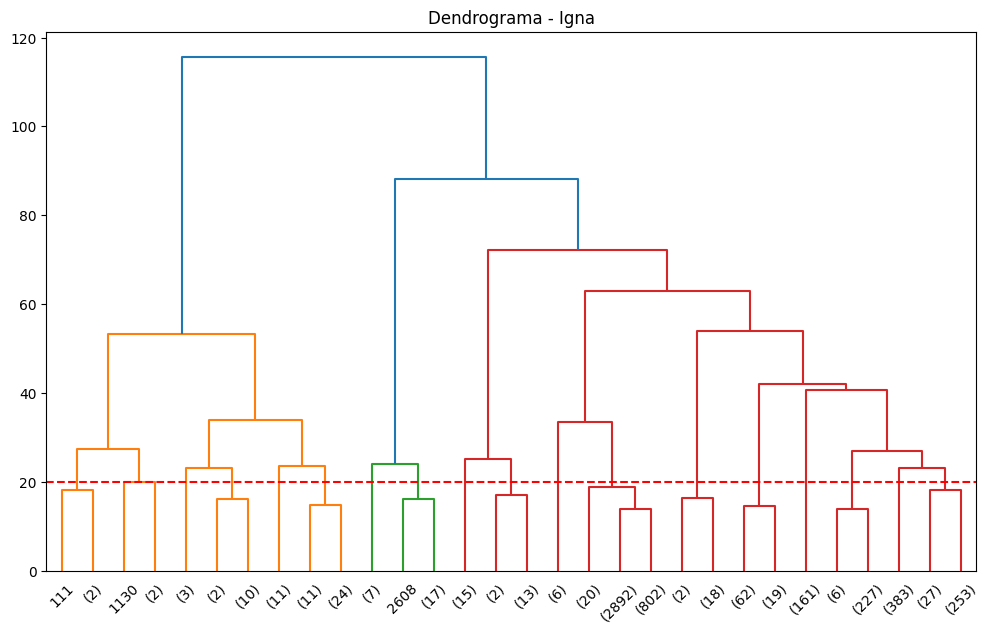

In [15]:
# Calcular matriz de distancia y linkage

linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.axhline(y=20, color='r', linestyle='--')
plt.title('Dendrograma - Igna')
plt.show()

In [25]:
from scipy.cluster.hierarchy import fcluster

n_clusters = 4

df['cluster_hier'] = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

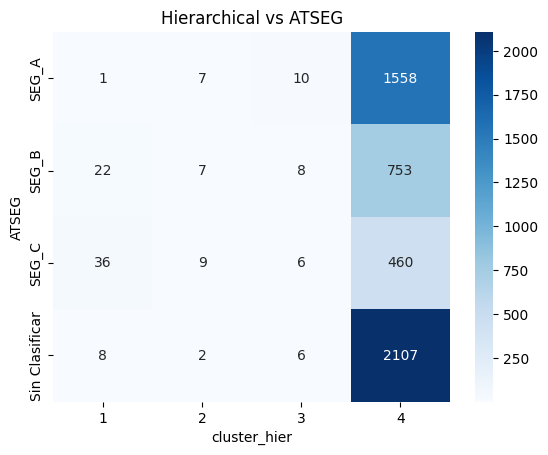

In [26]:
if 'ATSEG' in df.columns:
    crosstab = pd.crosstab(
        df['ATSEG'].fillna('Sin Clasificar'),
        df['cluster_hier']
    )

    sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
    plt.title('Hierarchical vs ATSEG')
    plt.show()

In [ ]:
if 'ATSEG' in df.columns:
    crosstab = pd.crosstab(df['ATSEG'].fillna('Sin Clasificar'), df['cluster_gmm'])
    sns.heatmap(crosstab, annot=True, fmt='d')
    plt.title('Igna: Clusters vs ATSEG')
    plt.show()

### Gaussian Mixture Models (GMM)

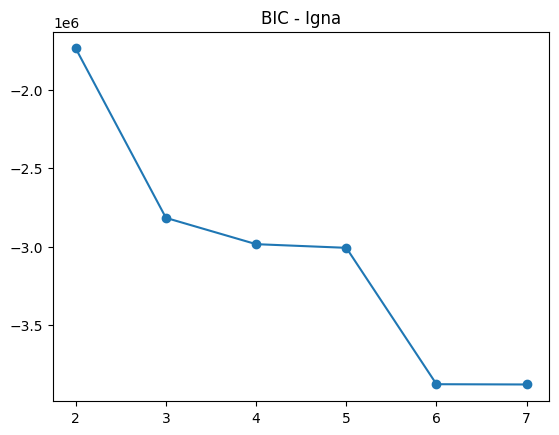

In [16]:
# Método del codo para GMM
n_components_range = range(2, 8)
bics = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X2_scaled)
    bics.append(gmm.bic(X2_scaled))

plt.plot(n_components_range, bics, 'o-')
plt.title('BIC - Igna')
plt.show()

In [17]:
gmm = GaussianMixture(n_components=3, random_state=42)
df2['cluster_gmm'] = gmm.fit_predict(X2_scaled)
df['cluster_gmm'] = gmm.predict(X_scaled)

print(df2['cluster_gmm'].value_counts())

cluster_gmm
0    86210
2    12151
1     1639
Name: count, dtype: int64


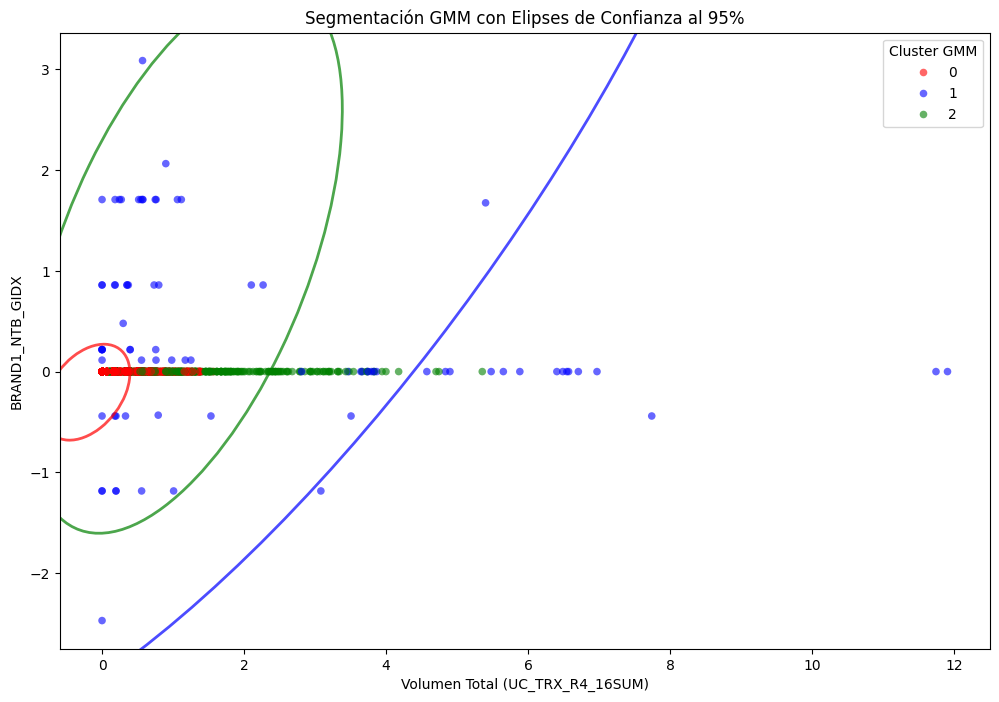

UC_TRX
BRAND1_NTB_GIDX


In [24]:
def plot_gmm_ellipses(gmm, X, ax, colors, alpha=0.3):
    """Dibuja elipses de confianza al 95% para cada componente GMM"""
    for i, color in enumerate(colors):
        mean = gmm.means_[i][:2]
        cov = gmm.covariances_[i][:2, :2]
        
        # Calcular elipse al 95% de confianza (chi2 con df=2)
        v, w = np.linalg.eigh(cov)
        v = 2 * np.sqrt(2.447 * v) 
        angle = np.arctan2(w[1, 0], w[0, 0])
        ell = Ellipse(xy=mean, width=v[0], height=v[1], angle=np.degrees(angle),
                      edgecolor=color, facecolor='none', linewidth=2, alpha=0.7)
        ax.add_patch(ell)

# Muestrear para evitar overplotting
sample_df = df2.sample(n=5000, random_state=42)

plt.figure(figsize=(12, 8))
ax = plt.gca()
colors = ['red', 'blue', 'green']

variances = df2[features].var().sort_values(ascending=False)

x_col = variances.index[0]
#y_col = variances.index[1]
y_col = 'BRAND1_NTB_GIDX'

sns.scatterplot(data=sample_df, x=x_col, y=y_col, 
                hue='cluster_gmm', palette=colors, alpha=0.6, s=30, edgecolor='none')

# Dibujar elipses de confianza (usa las medias y covarianzas del GMM original)
plot_gmm_ellipses(gmm, X2_scaled, ax, colors)

plt.title('Segmentación GMM con Elipses de Confianza al 95%')
plt.xlabel('Volumen Total (UC_TRX_R4_16SUM)')
plt.ylabel('BRAND1_NTB_GIDX')
plt.legend(title='Cluster GMM')
plt.show()
print(x_col)
print(y_col)

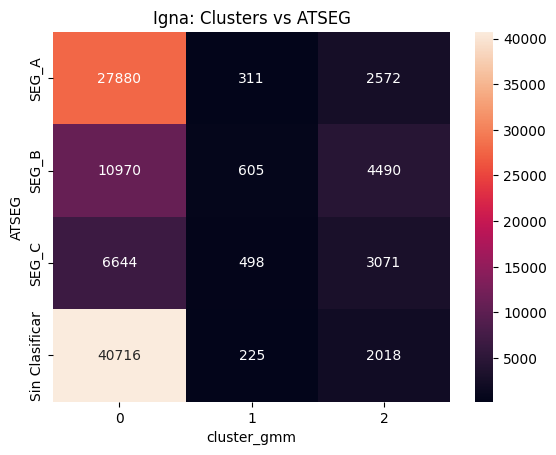

In [20]:
if 'ATSEG' in df2.columns:
    crosstab = pd.crosstab(df2['ATSEG'].fillna('Sin Clasificar'), df2['cluster_gmm'])
    sns.heatmap(crosstab, annot=True, fmt='d')
    plt.title('Igna: Clusters vs ATSEG')
    plt.show()